# MovieLens 32M: Exploratory Data Analysis (EDA)

The goal of this notebook is to understand the shape, distribution, and sparsity of the MovieLens 32M dataset. To handle the 32 million ratings efficiently without running out of memory, we will use **Polars** with LazyFrames for data manipulation.

Dataset files:
* `ratings.csv`: User ratings for movies.
* `movies.csv`: Movie titles and genres.
* `tags.csv`: User-generated metadata tags.

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Ingestion (Lazy Loading)
Instead of loading the entire CSVs into RAM immediately, we use `pl.scan_csv()` to create a LazyFrame. Polars will build an optimized query plan and only execute it when we call `.collect()`. 

We will also define schemas to ensure optimal memory usage (e.g., using 32-bit integers instead of 64-bit where possible).

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
DATA_DIR = "./data/ml-32m/"

ratings_lf = pl.scan_csv(
    f"{DATA_DIR}ratings.csv",
    schema_overrides={
        "userId": pl.Int32,
        "movieId": pl.Int32,
        "rating": pl.Float32,
        "timestamp": pl.Int64
    }
)

movies_lf = pl.scan_csv(
    f"{DATA_DIR}movies.csv",
    schema_overrides={
        "movieId": pl.Int32,
        "title": pl.Utf8,
        "genres": pl.Utf8
    }
)

tags_lf = pl.scan_csv(
    f"{DATA_DIR}tags.csv",
    schema_overrides={
        "userId": pl.Int32,
        "movieId": pl.Int32,
        "tag": pl.Utf8,
        "timestamp": pl.Int64
    }
)

print("LazyFrames created successfully.")

LazyFrames created successfully.


## 2. Initial Inspection
Let's take a quick look at the first few rows of our ratings data. Calling `.head(10).collect()` tells Polars to only read the first 10 rows of the CSV, which is practically instantaneous.

Timestamps represent seconds since midnight Coordinated Universal Time (UTC) of January 1, 1970. We will convert these to human-readable datetimes.

In [4]:
ratings_lf.head(10).collect()

userId,movieId,rating,timestamp
i32,i32,f32,i64
1,17,4.0,944249077
1,25,1.0,944250228
1,29,2.0,943230976
1,30,5.0,944249077
1,32,5.0,943228858
1,34,2.0,943228491
1,36,1.0,944249008
1,80,5.0,944248943
1,110,3.0,943231119


In [5]:
ratings_lf = ratings_lf.with_columns(
    pl.from_epoch(pl.col("timestamp"), time_unit="s").alias("datetime")
)

ratings_lf.head(10).collect()

userId,movieId,rating,timestamp,datetime
i32,i32,f32,i64,datetime[μs]
1,17,4.0,944249077,1999-12-03 19:24:37
1,25,1.0,944250228,1999-12-03 19:43:48
1,29,2.0,943230976,1999-11-22 00:36:16
1,30,5.0,944249077,1999-12-03 19:24:37
1,32,5.0,943228858,1999-11-22 00:00:58
1,34,2.0,943228491,1999-11-21 23:54:51
1,36,1.0,944249008,1999-12-03 19:23:28
1,80,5.0,944248943,1999-12-03 19:22:23
1,110,3.0,943231119,1999-11-22 00:38:39


## 3. Ratings Distribution
Ratings are made on a 5-star scale, with half-star increments (0.5 stars - 5.0 stars). Let's analyze the distribution of these ratings to see if users tend to be generous or critical.

In [6]:
rating_counts = (
    ratings_lf
    .group_by("rating")
    .agg(pl.count("userId").alias("count"))
    .sort("rating")
    .collect()
)

rating,count
f32,u32
0.5,525132
1.0,946675
1.5,531063
2.0,2028622
2.5,1685386
3.0,6054990
3.5,4290105
4.0,8367654
4.5,2974000


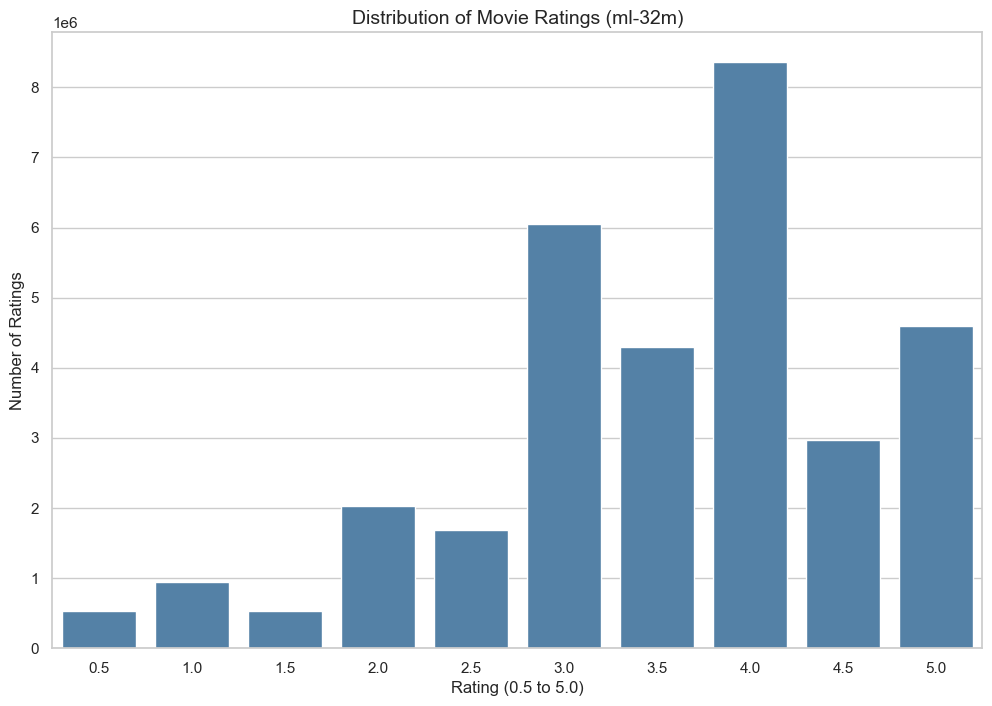

In [7]:
display(rating_counts)

plt.figure(figsize=(12, 8))
sns.barplot(
    x=rating_counts["rating"].to_list(), 
    y=rating_counts["count"].to_list(), 
    color="steelblue"
)
plt.title("Distribution of Movie Ratings (ml-32m)", fontsize=14)
plt.xlabel("Rating (0.5 to 5.0)", fontsize=12)
plt.ylabel("Number of Ratings", fontsize=12)
plt.show()

## 4. Dataset Sparsity
Recommender systems suffer from the "cold start" and sparsity problems. We need to calculate the exact sparsity of our user-item matrix. 

In [8]:
sparsity_stats = (
    ratings_lf
    .select(
        pl.col("userId").n_unique().alias("unique_users"),
        pl.col("movieId").n_unique().alias("unique_movies"),
        pl.len().alias("total_ratings")
    )
    .collect()
)

n_users = sparsity_stats["unique_users"][0]
n_movies = sparsity_stats["unique_movies"][0]
n_ratings = sparsity_stats["total_ratings"][0]

matrix_size = n_users * n_movies
sparsity = 1 - (n_ratings / matrix_size)

print(f"Total Unique Users: {n_users:,}")
print(f"Total Unique Movies: {n_movies:,}")
print(f"Total Ratings: {n_ratings:,}")
print("-" * 30)
print(f"Matrix Sparsity: {sparsity * 100:.4f}%")

Total Unique Users: 200,948
Total Unique Movies: 84,432
Total Ratings: 32,000,204
------------------------------
Matrix Sparsity: 99.8114%


## 5. The Long Tail: Movie Popularity
In most recommendation systems, a tiny fraction of items gets the vast majority of interactions (blockbusters), while the rest form a "long tail" of niche content. 

Let's group our ratings by `movieId` to see how many ratings the average movie gets, and identify if we need to filter out ultra-obscure movies before modeling to reduce noise.

In [9]:
movie_activity = (
    ratings_lf
    .group_by("movieId")
    .agg(pl.count("userId").alias("num_ratings"))
    .join(
        movies_lf.select(["movieId", "title"]), 
        on="movieId", 
        how="left"
    )
    .select(["movieId", "title", "num_ratings"])
    .sort("num_ratings", descending=True)
    .collect()
)

Top 5 Most Rated Movies:


movieId,title,num_ratings
i32,str,u32
318,"""Shawshank Redemption, The (199…",102929
356,"""Forrest Gump (1994)""",100296
296,"""Pulp Fiction (1994)""",98409
2571,"""Matrix, The (1999)""",93808
593,"""Silence of the Lambs, The (199…",90330
260,"""Star Wars: Episode IV - A New …",85010
2959,"""Fight Club (1999)""",77332
480,"""Jurassic Park (1993)""",75233
527,"""Schindler's List (1993)""",73849


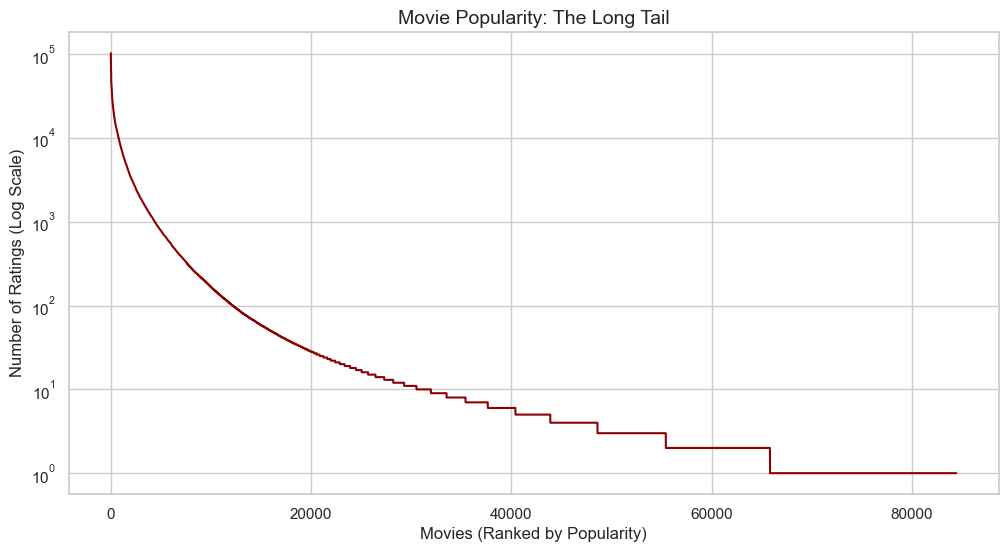


Movie Rating Statistics:


statistic,num_ratings
str,f64
"""count""",84432.0
"""null_count""",0.0
"""mean""",379.005638
"""std""",2592.439791
"""min""",1.0
"""25%""",2.0
"""50%""",5.0
"""75%""",25.0
"""max""",102929.0


In [10]:
print("Top 5 Most Rated Movies:")
display(movie_activity.head(10))

plt.figure(figsize=(12, 6))
plt.plot(movie_activity["num_ratings"].to_list(), color='darkred')
plt.title("Movie Popularity: The Long Tail", fontsize=14)
plt.xlabel("Movies (Ranked by Popularity)", fontsize=12)
plt.ylabel("Number of Ratings (Log Scale)", fontsize=12)
plt.yscale('log') 
plt.show()

print("\nMovie Rating Statistics:")
display(movie_activity.select(pl.col("num_ratings")).describe())

## 6. User Activity Distribution
We know from the dataset documentation that all selected users were required to have rated at least 20 movies. Let's verify this and see if we have "power users" who have rated thousands of movies, as they can heavily skew collaborative filtering algorithms.

In [11]:
user_activity = (
    ratings_lf
    .group_by("userId")
    .agg(pl.count("movieId").alias("num_ratings"))
    .sort("num_ratings", descending=True)
    .collect()
)

p99 = user_activity.select(pl.col("num_ratings").quantile(0.99)).item()
p95 = user_activity.select(pl.col("num_ratings").quantile(0.95)).item()

display(user_activity.select(pl.col("num_ratings")).describe())

statistic,num_ratings
str,f64
"""count""",200948.0
"""null_count""",0.0
"""mean""",159.246193
"""std""",282.025462
"""min""",20.0
"""25%""",36.0
"""50%""",73.0
"""75%""",167.0
"""max""",33332.0


99% of users have rated 1290.0 or fewer movies.
95% of users have rated 571.0 or fewer movies.


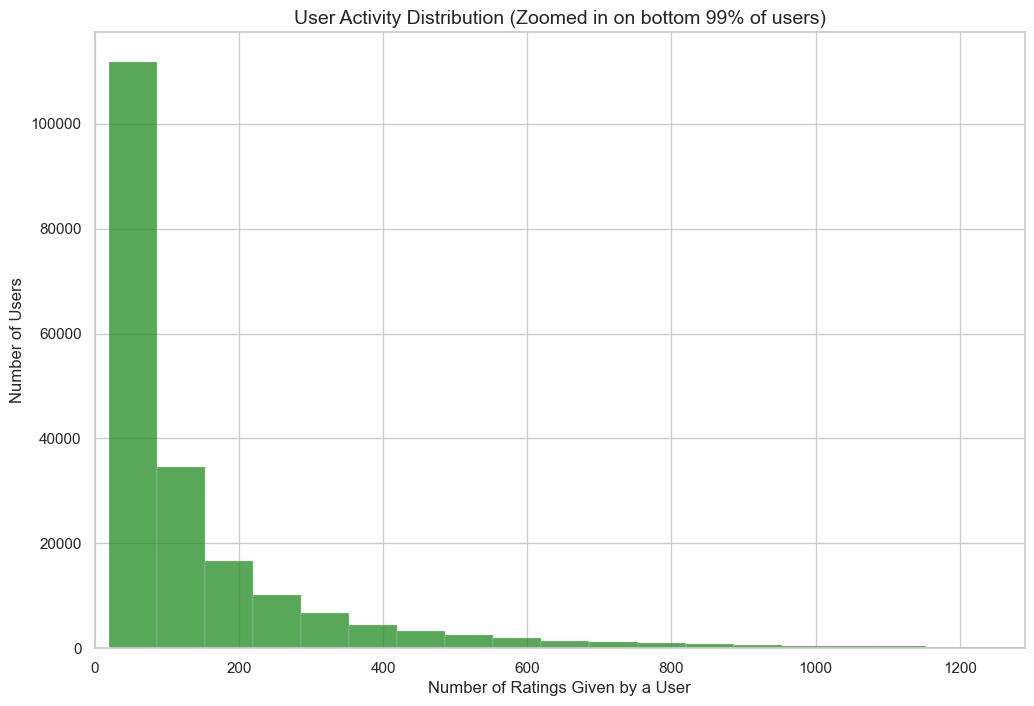

In [12]:
print(f"99% of users have rated {p99} or fewer movies.")
print(f"95% of users have rated {p95} or fewer movies.")

plt.figure(figsize=(12, 8))
sns.histplot(
    x=user_activity["num_ratings"].to_list(), 
    bins=500, 
    color='forestgreen'
)
plt.title(f"User Activity Distribution (Zoomed in on bottom 99% of users)", fontsize=14)
plt.xlabel("Number of Ratings Given by a User", fontsize=12)
plt.ylabel("Number of Users", fontsize=12)
plt.xlim(0, p99)
plt.show()